![banner](./images/banner.png)

### Monitoring disturbance in Congo Basin Peatlands with integrated alerts

With this code you can:

1. access RADD, GLAD-L and DIST real-time deforestation alerts
2. merge them and add attributes to determine if the fire is in a forest concession, protected area, peatland
3. view the data and preliminary analysis
4. export detections to a GEE asset you can view in SEPAL, upload centroids to Google drive for further analysis and visualisation
5. export centroids in peatland classes to geoJSON for validation in Open Foris Ground

In [1]:
import geemap, ee
from pathlib import Path
import numpy as np
import pandas as pd
import requests
import geopandas as gpd
from matplotlib import pyplot as plt
from matplotlib import font_manager
import geopandas as gpd
from shapely.geometry import box
import rasterio
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from shapely.geometry import Point
import folium
import geemap.foliumap as foliumap
from folium.plugins import HeatMap
from datetime import datetime
from datetime import datetime, timedelta
import time
import gspread
import warnings
from io import StringIO
import json
from tqdm import tqdm
import shapely.geometry
from rasterio.sample import sample_gen
from pathlib import Path
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
from google.oauth2.credentials import Credentials

In [39]:
import ee, geemap
print("geemap:", geemap.__version__)
print("earthengine-api:", ee.__version__)

geemap: 0.36.6
earthengine-api: 1.1.5rc0


In [2]:
#enter gee project name from your google earth engine console
project = 'gee-faocongo'

In [3]:
ee.Authenticate()

True

In [4]:
import ee
ee.Initialize(project=project)

In [5]:
# Generate today's date in YYYY-DD-MM format
end_date = datetime.now().strftime("%Y-%m-%d")

In [6]:
start_date = ee.Date('2025-06-01')

##### get project data

In [42]:
# Area of interest
aoi = ee.FeatureCollection('projects/congopeatlands/assets/PeatlandsAOI').geometry()

In [8]:
# Admin 1 areas
adm1 = ee.FeatureCollection('projects/congopeatlands/assets/peatlands_adm1')

In [9]:
# protected areas
PAs = ee.FeatureCollection('projects/congopeatlands/assets/peatlands_PAs')

In [10]:
# forest concessions
fc_COG = ee.FeatureCollection('projects/congopeatlands/assets/forest_concessions_COG')
fc_COD = ee.FeatureCollection('projects/congopeatlands/assets/forest_concessions_COD')

In [11]:
# Peatlands crezee
peatlands = ee.Image('projects/congopeatlands/assets/LandCover_Crezee_2022')
peatlands_buffer = ee.Image('projects/congopeatlands/assets/LandCover_Crezee_2022_500mbuffer')

In [12]:
peat_palm = peatlands_buffer.eq(4)
peat_hardwood = peatlands_buffer.eq(5)
peat_edge = peatlands_buffer.eq(6)
peat_raster = peat_palm.multiply(1).add(peat_hardwood.multiply(2)).add(peat_edge.multiply(3))

##### get alert data

In [13]:
radd = ee.ImageCollection('projects/radar-wur/raddalert/v1')
radd_alert = (
    radd.filterMetadata('layer', 'contains', 'alert')
        .filterMetadata('geography', 'contains', 'af')
        .filterBounds(aoi)
        .filterBounds(adm1)
        .sort('system:time_end', False)
        .first()
)
radd_date = radd_alert.select('Date').clip(aoi)
radd_2025 = radd_date.gte(25000)
radd_date_2025 = radd_date.updateMask(radd_2025).subtract(25000)
radd_conf_2025 = radd_alert.select('Alert').updateMask(radd_2025)

In [14]:
count_radd = radd_date_2025.selfMask().reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=aoi,
    scale=1000,
    maxPixels=1e9
)

print('RADD alerts:', count_radd.getInfo())

RADD alerts: {'Date': 59942}


In [15]:
# GLAD-L (Landsat alerts)
glad = ee.ImageCollection("projects/glad/alert/UpdResult").filterBounds(aoi).select(['alertDate25', 'conf25']).mosaic()
glad_date_2025 = glad.select('alertDate25')
glad_conf_2025 = glad.select('conf25')
glad_conf = glad_conf_2025.updateMask(glad_conf_2025.gt(25))

In [16]:
glad_alert_count = glad_date_2025.selfMask().toInt8().reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=aoi,
    scale=1000,
    maxPixels=1e13
)

print('GLAD-L alerts:', glad_alert_count.getInfo())

GLAD-L alerts: {'alertDate25': 160163}


In [17]:
# DIST alerts
# Define start date and convert to Julian days since 2020-12-31
start_julian = start_date.difference(start_date, 'day').int()

# Load the layers
folder = "projects/glad/HLSDIST/current"
VEGDISTSTATUS = ee.ImageCollection(f"{folder}/VEG-DIST-STATUS").filterBounds(aoi).mosaic()
VEGDISTDATE = ee.ImageCollection(f"{folder}/VEG-DIST-DATE").filterBounds(aoi).mosaic()

# Adjust VEGDISTDATE to be days since Jan 1, 2025
dist_date_2025 = VEGDISTDATE.subtract(
    ee.Date('2025-01-01').difference('2020-12-31', 'day')
).int()

# Filter VEGDISTSTATUS using updated VEGDISTDATE
dist_status_2025 = VEGDISTSTATUS.updateMask(dist_date_2025.gte(start_julian))

In [18]:
dist_count = dist_date_2025.selfMask().reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=aoi,
    scale=1000,
    maxPixels=1e9
)

print('DIST valid pixel count:', dist_count.getInfo())

DIST valid pixel count: {'b1': 48299}


##### intersect alerts with peatlands

In [68]:
radd_peat = radd_date_2025.gt(0).unmask().updateMask(peat_raster).clip(adm1)
glad_peat = glad_date_2025.gt(0).unmask().updateMask(peat_raster).clip(adm1)
dist_peat = dist_date_2025.gt(0).unmask().updateMask(peat_raster).clip(adm1)
overlap = radd_mask.add(glad_mask).add(dist_mask).selfMask()

In [69]:
# --- Visualization parameters for each system ---
radd_vis = {'min': 1, 'max': 1, 'palette': ['ffcc00']}   # yellow for RADD
glad_vis = {'min': 1, 'max': 1, 'palette': ['00ffff']}   # cyan for GLAD
dist_vis = {'min': 1, 'max': 1, 'palette': ['ff0000']}   # red for DISTURBANCE
overlap_vis =  {'min': 1, 'max': 3, 'palette': ['blue','orange','purple']}


# ---- Get map center from AOI ----
center = aoi.centroid().coordinates().getInfo()

# ---- Create map ----
m = folium.Map(
    location=[center[1], center[0]],
    zoom_start=8,
    tiles="CartoDB Dark Matter"  # dark basemap
)

# ---- Add satellite basemap ----
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Satellite Basemap",
    overlay=False,
    control=True
).add_to(m)

# --- Helper function to add EE layers ---
def add_ee_layer(m, ee_object, vis_params, name):
    map_id_dict = ee.Image(ee_object).getMapId(vis_params)
    folium.TileLayer(
        tiles=map_id_dict["tile_fetcher"].url_format,
        attr="Google Earth Engine",
        name=name,
        overlay=True,
        control=True,
    ).add_to(m)

# --- Add each layer separately ---
add_ee_layer(m, radd_peat.clip(aoi).selfMask(), radd_vis, "RADD")
add_ee_layer(m, glad_peat.clip(aoi).selfMask(), glad_vis, "GLAD-L")
add_ee_layer(m, dist_peat.clip(aoi).selfMask(), dist_vis, "DIST-alert")
add_ee_layer(m, overlap.clip(aoi).selfMask(), overlap_vis, "overlap")

# --- Layer control ---
folium.LayerControl(collapsed=False).add_to(m)

# --- Add a simple legend ---
legend_html = """
<div style="
    position: fixed;
    bottom: 50px; left: 50px; width: 180px; z-index:9999; font-size:14px;
    background-color: rgba(25, 25, 25, 0.8);
    border: 2px solid lightgray;
    border-radius: 6px;
    padding: 10px;
    color: white;
">
<b>Alert Masks (2025)</b><br>
<i style="background:#ffcc00;width:12px;height:12px;float:left;margin-right:8px;opacity:0.8;"></i>RADD<br>
<i style="background:#00ffff;width:12px;height:12px;float:left;margin-right:8px;opacity:0.8;"></i>GLAD-L<br>
<i style="background:#ff0000;width:12px;height:12px;float:left;margin-right:8px;opacity:0.8;"></i>DIST alert
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# --- Display the map ---
m

##### determine alerts by month

In [71]:
radd_mask = radd_date_2025.gt(0).updateMask(peat_raster)
glad_mask = glad_date_2025.gt(0).updateMask(peat_raster)
dist_mask = dist_date_2025.gt(0).updateMask(peat_raster)

In [81]:
aoi = peat_raster.geometry()
scale = 500
tileScale = 16

In [82]:
def get_julian_values(image, mask):
    img = image.updateMask(mask).updateMask(image.gt(0))
    values = img.sample(
        region=aoi,
        scale=scale,
        geometries=False
    ).aggregate_array(img.bandNames().get(0))
    return values

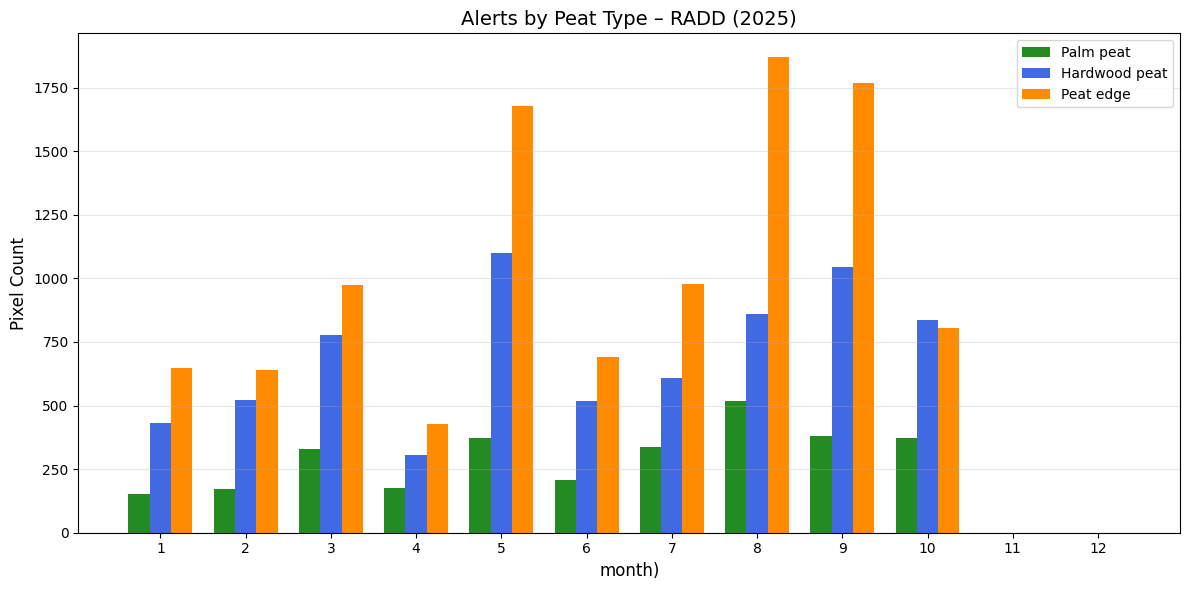

In [83]:
# --- RADD ---
radd_vals_palm = np.array(get_julian_values(radd_date_2025.updateMask(radd_mask), peat_palm).getInfo())
radd_vals_hard = np.array(get_julian_values(radd_date_2025.updateMask(radd_mask), peat_hardwood).getInfo())
radd_vals_edge = np.array(get_julian_values(radd_date_2025.updateMask(radd_mask), peat_edge).getInfo())

bins = np.arange(0, 361, 30)
bin_ids = np.arange(1, 13)

radd_counts_palm, _ = np.histogram(radd_vals_palm, bins=bins)
radd_counts_hard, _ = np.histogram(radd_vals_hard, bins=bins)
radd_counts_edge, _ = np.histogram(radd_vals_edge, bins=bins)

bar_width = 0.25
palm_x = bin_ids - bar_width
hard_x = bin_ids
edge_x = bin_ids + bar_width

plt.figure(figsize=(12, 6))
plt.bar(palm_x, radd_counts_palm, width=bar_width, color='forestgreen', label='Palm peat')
plt.bar(hard_x, radd_counts_hard, width=bar_width, color='royalblue', label='Hardwood peat')
plt.bar(edge_x, radd_counts_edge, width=bar_width, color='darkorange', label='Peat edge')

plt.title('Alerts by Peat Type – RADD (2025)', fontsize=14)
plt.xlabel('month)', fontsize=12)
plt.ylabel('Pixel Count', fontsize=12)
plt.xticks(bin_ids, [str(i) for i in bin_ids])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --- GLAD ---
glad_vals_palm = np.array(get_julian_values(glad_date_2025.updateMask(glad_mask), peat_palm).getInfo())
glad_vals_hard = np.array(get_julian_values(glad_date_2025.updateMask(glad_mask), peat_hardwood).getInfo())
glad_vals_edge = np.array(get_julian_values(glad_date_2025.updateMask(glad_mask), peat_edge).getInfo())

bins = np.arange(0, 361, 30)
bin_ids = np.arange(1, 13)

glad_counts_palm, _ = np.histogram(glad_vals_palm, bins=bins)
glad_counts_hard, _ = np.histogram(glad_vals_hard, bins=bins)
glad_counts_edge, _ = np.histogram(glad_vals_edge, bins=bins)

bar_width = 0.25
palm_x = bin_ids - bar_width
hard_x = bin_ids
edge_x = bin_ids + bar_width

plt.figure(figsize=(12, 6))
plt.bar(palm_x, glad_counts_palm, width=bar_width, color='forestgreen', label='Palm peat')
plt.bar(hard_x, glad_counts_hard, width=bar_width, color='royalblue', label='Hardwood peat')
plt.bar(edge_x, glad_counts_edge, width=bar_width, color='darkorange', label='Peat edge')

plt.title('Alerts by Peat Type – GLAD (2025)', fontsize=14)
plt.xlabel('month)', fontsize=12)
plt.ylabel('Pixel Count', fontsize=12)
plt.xticks(bin_ids, [str(i) for i in bin_ids])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --- DIST ---
dist_vals_palm = np.array(get_julian_values(dist_date_2025.updateMask(dist_mask), peat_palm).getInfo())
dist_vals_hard = np.array(get_julian_values(dist_date_2025.updateMask(dist_mask).getInfo())
dist_vals_edge = np.array(get_julian_values(dist_date_2025.updateMask(dist_mask).getInfo())

bins = np.arange(0, 361, 30)
bin_ids = np.arange(1, 13)

dist_counts_palm, _ = np.histogram(dist_vals_palm, bins=bins)
dist_counts_hard, _ = np.histogram(dist_vals_hard, bins=bins)
dist_counts_edge, _ = np.histogram(dist_vals_edge, bins=bins)

bar_width = 0.25
palm_x = bin_ids - bar_width
hard_x = bin_ids
edge_x = bin_ids + bar_width

plt.figure(figsize=(12, 6))
plt.bar(palm_x, dist_counts_palm, width=bar_width, color='forestgreen', label='Palm peat')
plt.bar(hard_x, dist_counts_hard, width=bar_width, color='royalblue', label='Hardwood peat')
plt.bar(edge_x, dist_counts_edge, width=bar_width, color='darkorange', label='Peat edge')

plt.title('Alerts by Peat Type – DIST (2025)', fontsize=14)
plt.xlabel('month', fontsize=12)
plt.ylabel('Pixel Count', fontsize=12)
plt.xticks(bin_ids, [str(i) for i in bin_ids])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### overlap disturbance with land use

In [84]:
# Count alerts inside PAs
def count_alerts_in_fc(image, fc, scale=30):
    """Return total count of alert pixels (1s) within each feature of fc."""
    return image.reduceRegions(
        collection=fc,
        reducer=ee.Reducer.sum(),
        scale=scale
    )

radd_in = count_alerts_in_fc(radd_peat, PAs)
glad_in = count_alerts_in_fc(glad_peat, PAs)
dist_in = count_alerts_in_fc(dist_peat, PAs)

# Sum all PAs
radd_in_total = radd_in.aggregate_sum('sum').getInfo()
glad_in_total = glad_in.aggregate_sum('sum').getInfo()
dist_in_total = dist_in.aggregate_sum('sum').getInfo()

# --- Step 4: Count alerts outside PAs ---
# Create inverse mask for non-PA areas
pa_mask = ee.Image(1).clip(PAs).mask()
non_pa_mask = ee.Image(1).updateMask(pa_mask.Not())

radd_out = radd_bin.updateMask(non_pa_mask).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=adm1.geometry(),
    scale=500,
    maxPixels=1e13
).get('constant').getInfo()

glad_out = glad_bin.updateMask(non_pa_mask).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=adm1.geometry(),
    scale=500,
    maxPixels=1e13
).get('constant').getInfo()

dist_out = dist_bin.updateMask(non_pa_mask).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=adm1.geometry(),
    scale=500,
    maxPixels=1e13
).get('constant').getInfo()

# --- Step 5: Compile results into a table ---
data = {
    'System': ['RADD', 'GLAD', 'DISTURBANCE'],
    'Inside_PAs': [radd_in_total, glad_in_total, dist_in_total],
    'Outside_PAs': [radd_out, glad_out, dist_out]
}

df = pd.DataFrame(data)
df['Total'] = df['Inside_PAs'] + df['Outside_PAs']
print(df)

# --- Step 6: Plot results ---
ax = df.plot(
    x='System',
    y=['Inside_PAs', 'Outside_PAs'],
    kind='bar',
    stacked=False,
    color=['#1b9e77', '#d95f02'],
    figsize=(8,5)
)
plt.title("Alerts inside vs outside Protected Areas (Peatland extent)")
plt.ylabel("Number of alerts")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

NameError: name 'radd_bin' is not defined

##### export rasters

In [ ]:
export_scale = 10  # meters
asset_folder = 'projects/congopeatlands'  # 🔹 change to your own

task_radd = ee.batch.Export.image.toAsset(
    image=radd_peat.selfMask().clip(aoi),
    description='radd_peat_export',
    assetId='raddAlert_peatlands_'+end_date,
    region=radd_peat.geometry(),
    scale=export_scale,
    maxPixels=1e13
)
task_radd.start()

task_glad = ee.batch.Export.image.toAsset(
    image=glad_peat.selfMask().clip(aoi),
    description='glad_peat_export',
    assetId='gladAlert_peatlands_'+end_date,
    region=glad_peat.geometry(),
    scale=export_scale,
    maxPixels=1e13
)
task_glad.start()

task_dist = ee.batch.Export.image.toAsset(
    image=dist_peat.selfMask().clip(aoi),
    description='dist_peat_export',
    assetId='distAlert_peatlands_'+end_date,
    region=dist_peat.geometry(),
    scale=export_scale,
    maxPixels=1e13
)
task_dist.start()

In [ ]:
#export to Drive
export_scale = 10  # meters
folder = 'Congo_Peatlands'
# ---- RADD ----
task_radd = ee.batch.Export.image.toDrive(
    image=radd_peat.selfMask().clip(aoi),
    description='radd_peat_export',
    folder=folder,       # folder name in your Google Drive
    fileNamePrefix='raddAlters_peatlands_'+end_date,
    region=radd_peat.geometry(),
    scale=export_scale,
    maxPixels=1e13
)
task_radd.start()

# ---- GLAD ----
task_glad = ee.batch.Export.image.toDrive(
    image=glad_peat.selfMask().clip(aoi),
    description='glad_peat_export',
    folder=folder,       # folder name in your Google Drive,
    fileNamePrefix='gladAlerts_peatlands_'+end_date,
    region=glad_peat.geometry(),
    scale=export_scale,
    maxPixels=1e13
)
task_glad.start()

# ---- DISTURBANCE ----
task_dist = ee.batch.Export.image.toDrive(
    image=dist_peat.selfMask().clip(aoi),
    description='dist_peat_export',
    folder=folder,       # folder name in your Google Drive,
    fileNamePrefix='distAlerts_peatlands_'+end_date,
    region=dist_peat.geometry(),
    scale=export_scale,
    maxPixels=1e13
)
task_dist.start()

#check your GEE console to observe export

##### export centroids for analysis

In [ ]:
def extract_centroids(image, system_name, aoi, conf=None, status=None):
    """Extract cluster centroids with Julian date, optional confidence/status, and peat class."""

    # 1. Mask valid pixels (alerts > 0)
    img = image.updateMask(image.gt(0)).rename('julian_date')

    # 2. Connected components (8-connected) and remove single-pixel clusters
    cc = img.connectedComponents(ee.Kernel.square(1), 128)
    clusters = cc.select('labels')
    cluster_sizes = clusters.connectedPixelCount(128, True)
    clusters = clusters.updateMask(cluster_sizes.gt(1))

    # 3. Connected-component reduction: mean Julian date
    stats = img.addBands(clusters).reduceConnectedComponents(
        reducer=ee.Reducer.mean(),
        labelBand='labels'
    )

    # 4. Extract cluster centroids
    centroids = clusters.reduceToVectors(
        geometry=aoi,
        geometryType='centroid',
        scale=100,
        eightConnected=True,
        labelProperty='cluster_id',
        reducer=ee.Reducer.countEvery(),
        maxPixels=1e13
    )

    # 5. Add stats + coordinates
    def enrich(f):
        geom = f.geometry()
        props = stats.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=geom,
            scale=100,
            bestEffort=True
        )
        return f.setMulti(props).set({
            'system': system_name,
            'lat': geom.coordinates().get(1),
            'lon': geom.coordinates().get(0)
        })

    joined = centroids.map(enrich)

    # 6. Add confidence/status/peat class
    def add_fields(f):
        geom = f.geometry()
        d = {}
        if conf:
            d['confidence'] = conf.reduceRegion(
                ee.Reducer.mean(), geom, 100, bestEffort=True
            ).values().get(0)
        if status:
            d['status'] = status.reduceRegion(
                ee.Reducer.first(), geom, 100, bestEffort=True
            ).values().get(0)

        # Determine peat class priority: palm > hardwood > edge > none
        is_palm = peat_palm.reduceRegion(ee.Reducer.first(), geom, 100).values().get(0)
        is_hard = peat_hardwood.reduceRegion(ee.Reducer.first(), geom, 100).values().get(0)
        is_edge = peat_edge.reduceRegion(ee.Reducer.first(), geom, 100).values().get(0)

        peat_class = ee.Algorithms.If(is_palm, 'palm',
                      ee.Algorithms.If(is_hard, 'hardwood',
                      ee.Algorithms.If(is_edge, 'edge', 'none')))
        d['peat_class'] = peat_class

        return f.set(d)

    joined = joined.map(add_fields)

    # 7. Return only required properties
    return joined.select(['system', 'julian_date', 'lat', 'lon', 'confidence', 'status', 'peat_class'])


In [ ]:
glad_fc = extract_centroids(glad_date_2025, 'glad', aoi)
radd_fc = extract_centroids(radd_date_2025, 'radd', aoi)
dist_fc = extract_centroids(dist_date_2025, 'dist', aoi)

In [ ]:
def join_attributes(base_fc, overlay_fc, attribute_name):
    """Spatially joins overlay attribute to base_fc by intersection."""
    spatial_filter = ee.Filter.intersects(
        leftField='.geo',
        rightField='.geo',
        maxError=10
    )

    simple_join = ee.Join.simple()
    joined = simple_join.apply(base_fc, overlay_fc, spatial_filter)

    def copy_attribute(f):
        match = ee.Feature(f.get('primary'))
        return ee.Feature(f.get('primary')).set(attribute_name, match.get(attribute_name))

    return ee.FeatureCollection(joined).map(copy_attribute)

In [ ]:
def enrich_centroids(centroids, system_name):
    centroids = centroids.map(lambda f: f.set({
        'NAME': None,
        'ste_att_en': None,
        'desc_type': None,
        'gaul1_name': None,
        'iso3_code': None
    }))

    # 1. Protected Areas
    centroids = join_attributes(centroids, PAs, 'NAME')

    # 2. Forest Concessions – Congo
    centroids = join_attributes(centroids, fc_COG, 'ste_att_en')

    # 3. Forest Concessions – DRC
    centroids = join_attributes(centroids, fc_COD, 'desc_type')

    # 4. Admin boundaries (two attributes)
    centroids = join_attributes(centroids, adm1, 'gaul1_name')
    centroids = join_attributes(centroids, adm1, 'iso3_code')

    # Add centroid coordinates
    centroids = centroids.map(lambda f: f.set({
        'lat': f.geometry().coordinates().get(1),
        'lon': f.geometry().coordinates().get(0),
        'system': system_name
    }))

    return centroids

# ======================================================
# Apply to each dataset
# ======================================================
radd_fc_joined = enrich_centroids(radd_fc, 'radd')
glad_fc_joined = enrich_centroids(glad_fc, 'glad')
dist_fc_joined = enrich_centroids(dist_fc, 'veg')

In [ ]:
def format_for_export(fc):
    """Convert FeatureCollection to lat/lon table (no geometry)."""
    fc = fc.map(lambda f: f.set({
        'lat': f.geometry().coordinates().get(1),
        'lon': f.geometry().coordinates().get(0)
    }).setGeometry(None))  # remove geometry
    return fc

# === Format each dataset ===
radd_export = format_for_export(radd_fc_joined)
glad_export = format_for_export(glad_fc_joined)
dist_export = format_for_export(dist_fc_joined)

In [ ]:
first_feature = radd_export.first()
sample_name = first_feature.propertyNames().get(0).getInfo()
print("One property name:", sample_name)

In [ ]:
# Clean collections
radd_export = radd_export.filter(ee.Filter.notNull(['system:index']))
glad_export = glad_export.filter(ee.Filter.notNull(['system:index']))
dist_export = dist_export.filter(ee.Filter.notNull(['system:index']))

In [ ]:
# Strip geometry and limit to 1
sample_export = glad_export.map(lambda f: f.setGeometry(None)).limit(1)

# Export to Drive
sample_task = ee.batch.Export.table.toDrive(
    collection=sample_export,
    description='glad_sample_preview',
    folder='EarthEngineExports',
    fileNamePrefix='glad_sample_preview',
    fileFormat='CSV'
)
sample_task.start()

In [ ]:

# === Export to Drive ===
radd_task = ee.batch.Export.table.toDrive(
    collection=radd_export,
    description='radd_peatland_alerts_2025',
    folder='Congo_Peatlands',
    fileNamePrefix='radd_peatland_alerts_2025',
    fileFormat='CSV'
)
glad_task = ee.batch.Export.table.toDrive(
    collection=glad_export,
    description='glad_peatland_alerts_2025',
    folder='Congo_Peatlands',
    fileNamePrefix='glad_peatland_alerts_2025',
    fileFormat='CSV'
)
dist_task = ee.batch.Export.table.toDrive(
    collection=dist_export,
    description='dist_peatland_alerts_2025',
    folder='EarthEngineExports',
    fileNamePrefix='dist_peatland_alerts_2025',
    fileFormat='CSV'
)

# Start the tasks
radd_task.start()
glad_task.start()
dist_task.start()

In [ ]:
tasks = [radd_task, glad_task, dist_task]

for t in tasks:
    status = t.status()
    print(f"{status['description']}: {status['state']}")